# CodeAlpha Internship - Task 2
# Exploratory Data Analysis(EDA)
## Sales Data Analysis

**## 1.Introduction**
This project performs Exploratory Data Analysis (EDA) on a sales dataset.

The dataset contains information about salespersons, countries, products,
sales dates, sales amounts, and boxes shipped.

The purpose of this analysis is to understand the data, identify patterns
and trends, detect anomalies, test relationships between variables, and
generate meaningful business insights.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")


Libraries imported successfully!


In [5]:
df = pd.read_excel("/content/sample-data-10mins.xlsx")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685,184


## 2.Understanding the Dataset

In [8]:
df.shape

(1094, 6)

In [9]:
df.head(10)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,5376,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835,102


In [10]:
df.tail()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
1089,Karlen McCaffrey,Australia,Spicy Special Slims,2022-05-17,4410,323
1090,Jehu Rudeforth,USA,White Choc,2022-06-07,6559,119
1091,Ches Bonnell,Canada,Organic Choco Syrup,2022-07-26,574,217
1092,Dotty Strutley,India,Eclairs,2022-07-28,2086,384
1093,Karlen McCaffrey,India,70% Dark Bites,2022-05-23,5075,344


In [11]:
df.columns

Index(['Sales Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes Shipped'],
      dtype='object')

In [12]:
df.dtypes

,0
Sales Person,object
Country,object
Product,object
Date,datetime64[ns]
Amount,int64
Boxes Shipped,int64


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   1094 non-null   object        
 1   Country        1094 non-null   object        
 2   Product        1094 non-null   object        
 3   Date           1094 non-null   datetime64[ns]
 4   Amount         1094 non-null   int64         
 5   Boxes Shipped  1094 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 51.4+ KB


**## 3.Data Quality Check**

In [14]:
df.isnull().sum()

,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df[df['Amount'] < 0]

,Sales Person,Country,Product,Date,Amount,Boxes Shipped


In [17]:
df[df['Boxes Shipped'] < 0]

,Sales Person,Country,Product,Date,Amount,Boxes Shipped


**## 4.Statistical Summary**

In [18]:
df.describe()

,Date,Amount,Boxes Shipped
count,1094,1094.000000,1094.000000
mean,2022-05-03 09:04:56.160877568,5652.308044,161.797989
min,2022-01-03 00:00:00,7.000000,1.000000
25%,2022-03-02 00:00:00,2390.500000,70.000000
50%,2022-05-11 00:00:00,4868.500000,135.000000
75%,2022-07-04 00:00:00,8027.250000,228.750000
max,2022-08-31 00:00:00,22050.000000,709.000000
std,NaN,4102.442014,121.544145


In [19]:
df[['Amount', 'Boxes Shipped']].describe()

,Amount,Boxes Shipped
count,1094.000000,1094.000000
mean,5652.308044,161.797989
std,4102.442014,121.544145
min,7.000000,1.000000
25%,2390.500000,70.000000
50%,4868.500000,135.000000
75%,8027.250000,228.750000
max,22050.000000,709.000000


**## 5.Exploratory Questions**
Before analyzing the dataset, the following questions were identified:

1. Which country generates the highest total sales?
2. Which product generates the highest total sales?
3. Which salesperson generates the highest total sales?
4. How do sales change over time?
5. Which products have the highest number of boxes shipped?
6. Is there a relationship between sales amount and boxes shipped?
7. Are there unusually high or low sales transactions?

### 6.Sales Analysis by Country
### Question 1: Which country generates the highest total sales?

In [20]:
country_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

country_sales

,Amount
Country,
Australia,1137367
UK,1051792
India,1045800
USA,1035349
Canada,962899
New Zealand,950418


### Observation

Australia has the highest total sales with a total sales amount of 1,137,367.

The UK, India, and USA also show relatively high total sales, while New Zealand has the lowest total sales among the countries in the dataset.

### 7.Sales Analysis by Product
### Question 2: Which product generate the highest total sales?

In [21]:
product_sales = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)

product_sales

,Amount
Product,
Smooth Sliky Salty,349692
50% Dark Bites,341712
White Choc,329147
Peanut Butter Cubes,324842
Eclairs,312445
99% Dark & Pure,299796
85% Dark Bars,299229
Organic Choco Syrup,294700
Spicy Special Slims,293454


### Observation

Smooth Sliky Salty generates the highest total sales with a total sales amount of 349,692.

50% Dark Bites and White Choc are the next highest-selling products based on total sales amount.

### 8.Sales Analysis by Salesperson
### Question 3: Which salesperson generates the highest total sales?

In [22]:
salesperson_sales = df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False)

salesperson_sales

,Amount
Sales Person,
Ches Bonnell,320901
Oby Sorrel,316645
Madelene Upcott,316099
Brien Boise,312816
Kelci Walkden,311710
Van Tuxwell,303149
Dennison Crosswaite,291669
Beverie Moffet,278922
Kaine Padly,266490


9.Monthly Sales Analysis

Step 1: Create a Month column

In [23]:
df['Month'] = df['Date'].dt.month

Step 2: Calculate total sales for each month

In [24]:
monthly_sales = df.groupby('Month')['Amount'].sum().sort_index()

monthly_sales

,Amount
Month,
1,896105
2,699377
3,749483
4,674051
5,752892
6,865144
7,803425
8,743148


Step 3: Find the highest-sales month

In [26]:
monthly_sales.idxmax(), monthly_sales.max()

(np.int32(1), 896105)

step 4: Find the lowest-sales month

In [27]:
monthly_sales.idxmax(), monthly_sales.min()

(np.int32(1), 674051)

step 5 - Make it more professional

In [28]:
monthly_sales.index = pd.to_datetime(monthly_sales.index, format='%m').month_name()

monthly_sales

,Amount
Month,
January,896105
February,699377
March,749483
April,674051
May,752892
June,865144
July,803425
August,743148


Stepp 6 - Country-wise Sales Analysis

In [31]:
country_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

country_sales

,Amount
Country,
Australia,1137367
UK,1051792
India,1045800
USA,1035349
Canada,962899
New Zealand,950418


<Axes: title={'center': 'Total Sales by Country'}, xlabel='Country'>

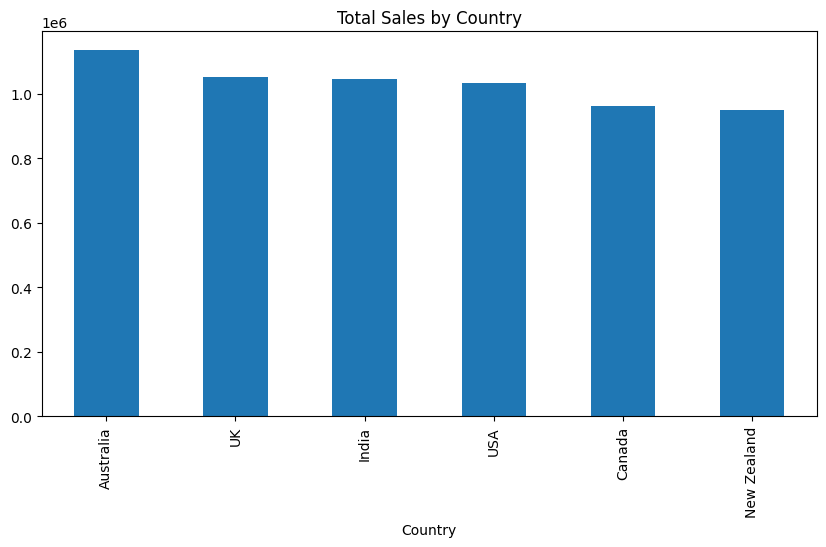

In [32]:
country_sales.plot(kind='bar', figsize=(10,5), title='Total Sales by Country')

Product-wise Sales Visualization

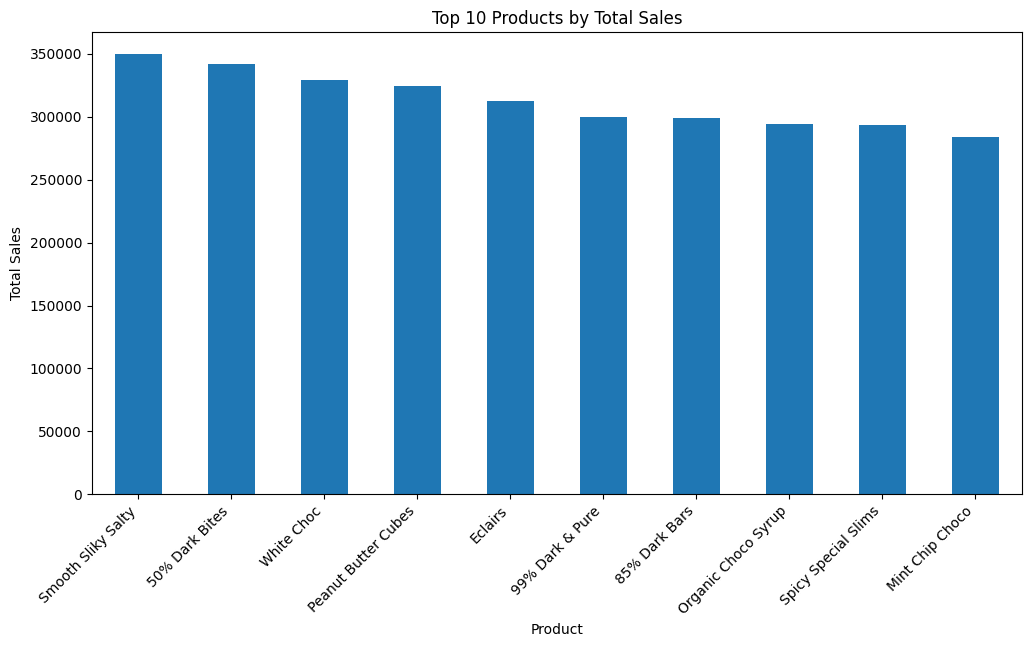

In [33]:
product_sales.head(10).plot(
    kind='bar',
    figsize=(12,6),
    title='Top 10 Products by Total Sales'
)

plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

Step 7 - Top 10 Products by Sales

In [34]:
top_products = product_sales.head(10)
top_products

,Amount
Product,
Smooth Sliky Salty,349692
50% Dark Bites,341712
White Choc,329147
Peanut Butter Cubes,324842
Eclairs,312445
99% Dark & Pure,299796
85% Dark Bars,299229
Organic Choco Syrup,294700
Spicy Special Slims,293454


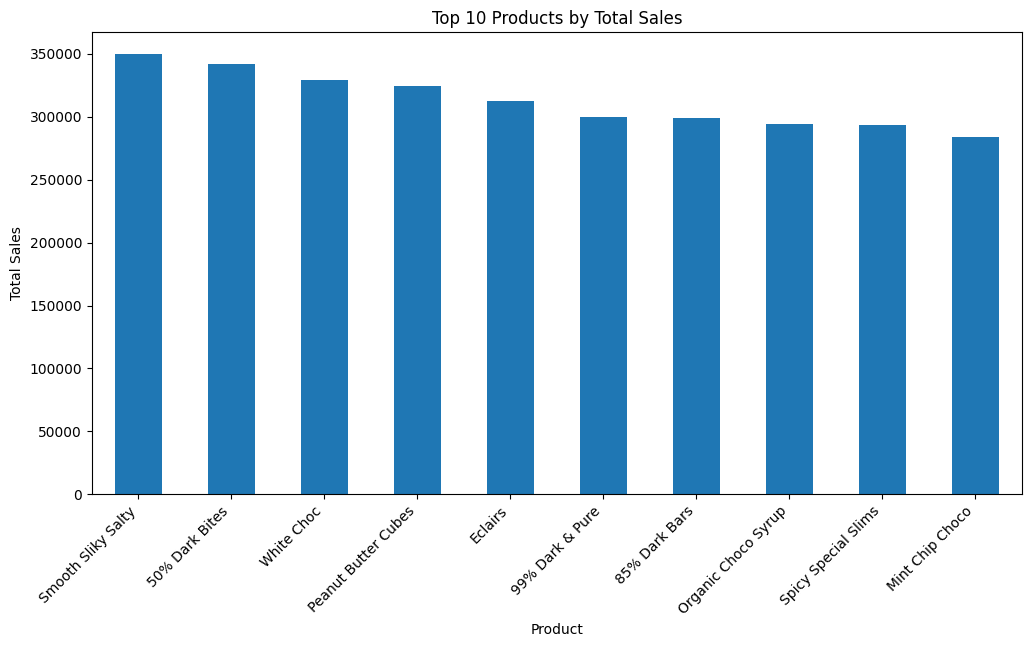

In [35]:
top_products.plot(
    kind='bar',
    figsize=(12,6),
    title='Top 10 Products by Total Sales'
)

plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

Step 8 - Salesperson Performance Analysis

In [36]:
salesperson_sales = df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False)

salesperson_sales

,Amount
Sales Person,
Ches Bonnell,320901
Oby Sorrel,316645
Madelene Upcott,316099
Brien Boise,312816
Kelci Walkden,311710
Van Tuxwell,303149
Dennison Crosswaite,291669
Beverie Moffet,278922
Kaine Padly,266490


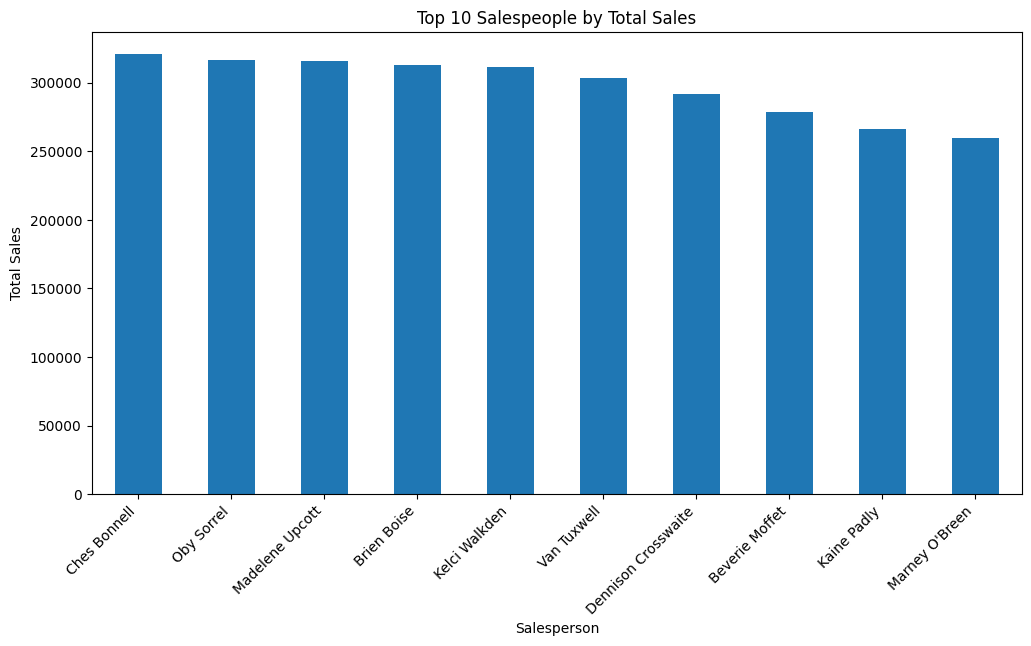

In [37]:
salesperson_sales.head(10).plot(
    kind='bar',
    figsize=(12,6),
    title='Top 10 Salespeople by Total Sales'
)

plt.xlabel('Salesperson')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

Step 9: Boxes Shipped by Country

In [6]:
country_boxes = df.groupby('Country')['Boxes Shipped'].sum().sort_values(ascending=False)

country_boxes

,Boxes Shipped
Country,
Australia,32647
Canada,31221
UK,30265
India,29470
USA,26824
New Zealand,26580


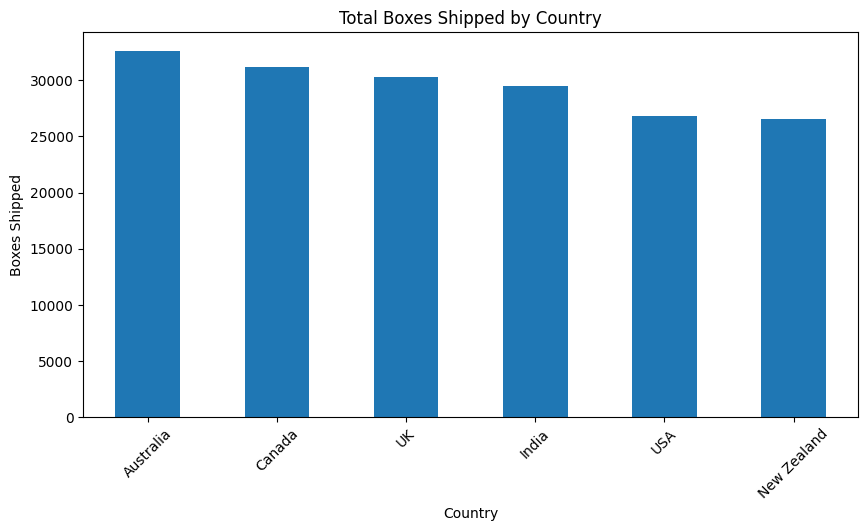

In [7]:
country_boxes.plot(
    kind='bar',
    figsize=(10,5),
    title='Total Boxes Shipped by Country'
)

plt.xlabel('Country')
plt.ylabel('Boxes Shipped')
plt.xticks(rotation=45)
plt.show()

### Insight
Australia has the highest number of boxes shipped, while New Zealand has the lowest. This indicates that Australia has the highest shipment volume among the countries in the dataset.

### Step 10: Sales by Product

In [8]:
product_sales = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)

product_sales.head(10)

,Amount
Product,
Smooth Sliky Salty,349692
50% Dark Bites,341712
White Choc,329147
Peanut Butter Cubes,324842
Eclairs,312445
99% Dark & Pure,299796
85% Dark Bars,299229
Organic Choco Syrup,294700
Spicy Special Slims,293454


### Insight

Smooth Sliky Salty recorded the highest total sales among the products, with total sales of 349,692.

The top 10 products show different levels of sales contribution, indicating that some products generate more revenue than others.

## Step 11: Sales Amount Distribution

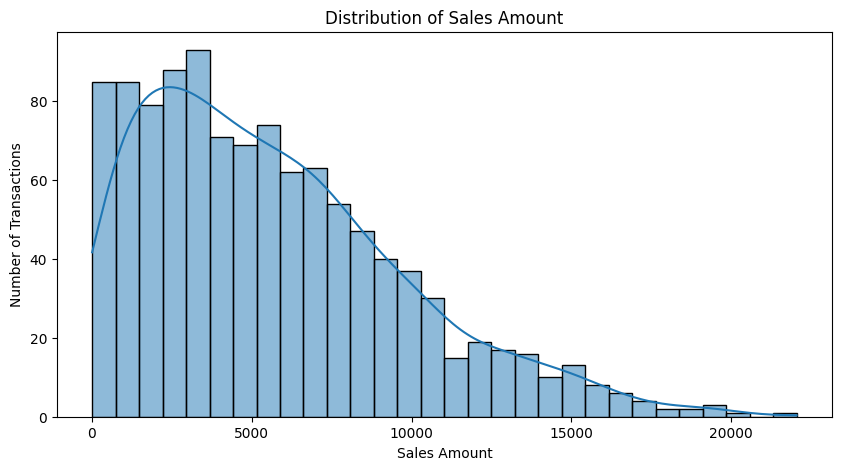

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=30, kde=True)

plt.title('Distribution of Sales Amount')
plt.xlabel('Sales Amount')
plt.ylabel('Number of Transactions')

plt.show()

### Insight:
The distribution of sales amount is positively skewed (right-skewed). Most transactions have relatively lower sales amounts, while a smaller number of transactions have very high sales amounts. This indicates the presence of high-value transactions and possible outliers.

Step 11: Outlier Analysis

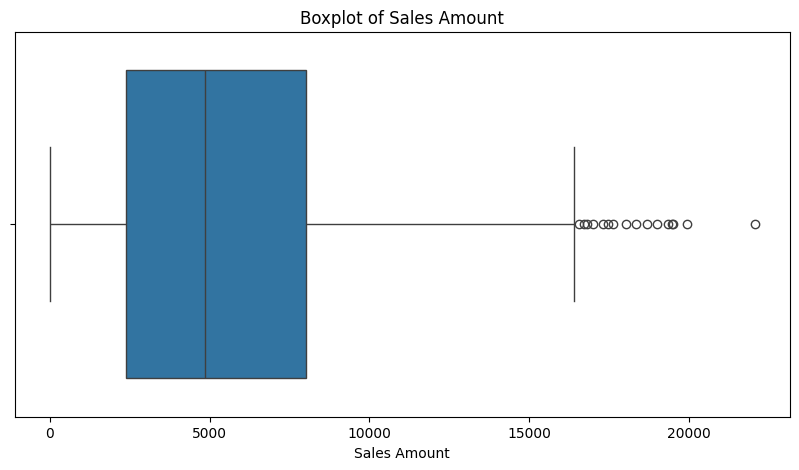

In [10]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Amount'])

plt.title('Boxplot of Sales Amount')
plt.xlabel('Sales Amount')

plt.show()

### Insight:
The boxplot helps identify the spread of sales amounts and potential outliers. Transactions appearing beyond the whiskers represent unusually high or low sales amounts and may require further investigation.

**10.Correlation Analysis**

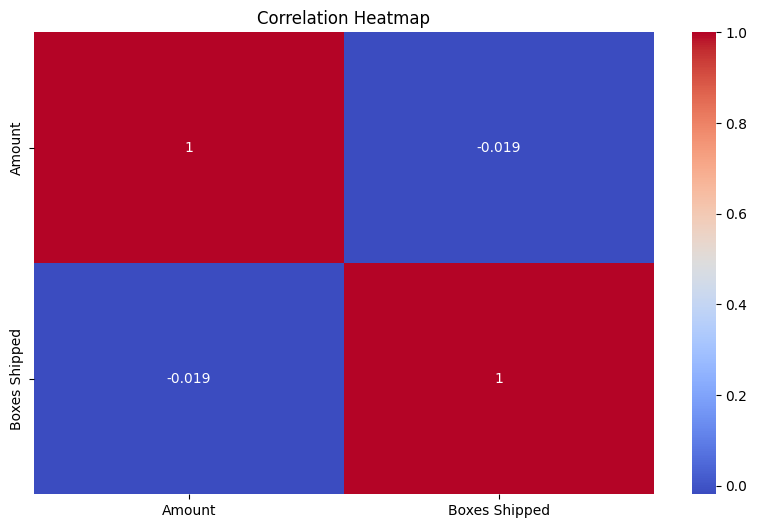

In [11]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

### Insight:
The correlation between Sales Amount and Boxes Shipped is very weak (-0.019), indicating that there is almost no linear relationship between these two variables.

# Final Conclusion

1. Sales are distributed across multiple countries, with Australia having the highest boxes shipped.
2. A few products contribute significantly to total sales.
3. Some salespersons generate higher revenue than others.
4. Sales amounts are positively skewed, with many low-value transactions and fewer high-value transactions.
5. Several high-value outliers are present in the dataset.
6. There is very little correlation between Sales Amount and Boxes Shipped.
7. Product performance, salesperson efficiency, and country-wise distribution provide valuable business insights.